## 線形回帰用サンプルデータセットの作成

このノートブックでは、線形回帰モデルの学習・検証に使用できるサンプルデータセットを作成します。


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# macOS用の日本語フォント設定（japanize_matplotlibの代替）
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化け対策

# 再現性のための乱数シード設定
np.random.seed(42)


## 1. 単純な線形回帰データ（1特徴量）

手動で `y = 3x + 5 + ノイズ` という関係を持つデータを生成します。


In [34]:
# サンプル数
n_samples = 100

# 特徴量 X を生成（0〜10の範囲）
X_simple = np.random.uniform(0, 10, n_samples)

# 目的変数 y を生成：y = 3x + 5 + ノイズ
true_slope = 3
true_intercept = 5
noise = np.random.normal(0, 2, n_samples)  # 標準偏差2のガウスノイズ
y_simple = true_slope * X_simple + true_intercept + noise

# DataFrameとして整形
df_simple = pd.DataFrame({
    'x': X_simple,
    'y': y_simple
})

print(f"データ形状: {df_simple.shape}")
print(f"真の係数: 傾き={true_slope}, 切片={true_intercept}")
df_simple.head(10)


データ形状: (100, 2)
真の係数: 傾き=3, 切片=5


,x,y
0,3.745401,16.410298
1,9.507143,32.923414
2,7.319939,27.143340
3,5.986585,18.984617
4,1.560186,9.241215
5,1.559945,10.394061
6,0.580836,9.698296
7,8.661761,29.948744
8,6.011150,21.416463
9,7.080726,25.238663


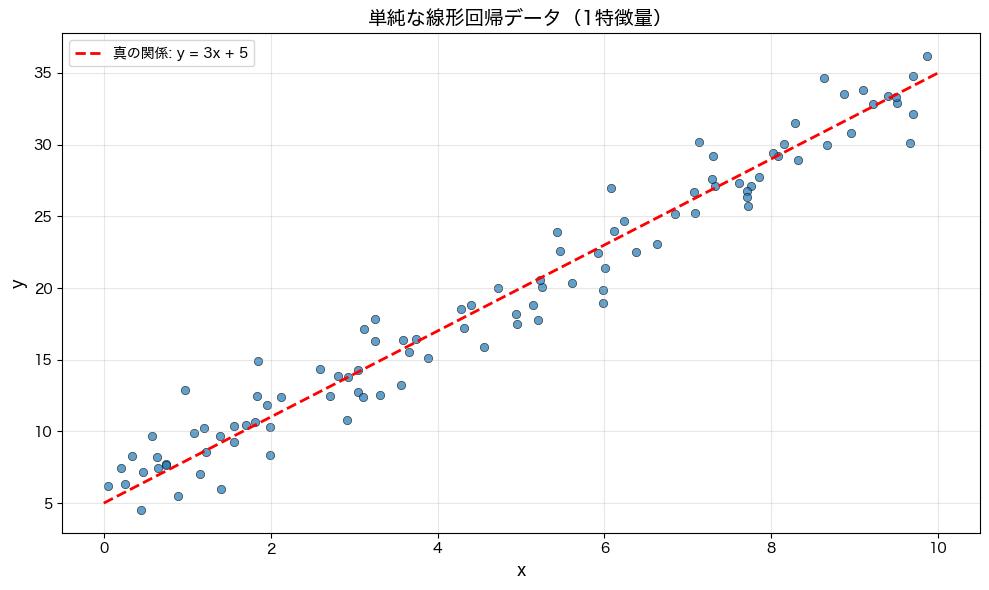

In [35]:
# 散布図で可視化
plt.figure(figsize=(10, 6))
plt.scatter(df_simple['x'], df_simple['y'], alpha=0.7, edgecolors='black', linewidth=0.5)
plt.plot([0, 10], [true_intercept, true_slope * 10 + true_intercept], 
         'r--', label=f'真の関係: y = {true_slope}x + {true_intercept}', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('単純な線形回帰データ（1特徴量）', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. 重回帰データ（複数特徴量）

`sklearn.datasets.make_regression` を使用して、複数の特徴量を持つデータを生成します。


In [36]:
# sklearn.datasets.make_regression を使用して重回帰データを生成
X_multi, y_multi, coef = make_regression(
    n_samples=200,      # サンプル数
    n_features=5,       # 特徴量の数
    n_informative=3,    # 目的変数に影響を与える特徴量の数
    noise=10,           # ノイズの標準偏差
    coef=True,          # 真の係数を返す
    random_state=42
)

# DataFrameとして整形
feature_names = [f'feature_{i+1}' for i in range(X_multi.shape[1])]
df_multi = pd.DataFrame(X_multi, columns=feature_names)
df_multi['target'] = y_multi

print(f"データ形状: {df_multi.shape}")
print(f"\n真の係数:")
for i, c in enumerate(coef):
    print(f"  feature_{i+1}: {c:.4f}")
    
df_multi.head(10)


データ形状: (200, 6)

真の係数:
  feature_1: 0.0000
  feature_2: 10.4568
  feature_3: 63.6430
  feature_4: 16.7483
  feature_5: 0.0000


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.385314,0.199060,-0.600217,0.462103,0.069802,-25.186432
1,0.130741,1.632411,-1.430141,-1.247783,-0.440044,-92.494948
2,-0.773010,0.224092,0.012592,-0.401220,0.097676,8.649970
3,-0.576771,-0.050238,-0.238948,0.270457,-0.907564,-0.472151
4,-0.575818,0.614167,0.757508,-0.220970,-0.530501,61.790098
5,-0.055548,1.628616,-1.380101,0.074095,-1.703382,-65.078889
6,1.696456,-1.280429,1.754794,0.606010,-2.081929,105.405488
7,1.179440,0.491919,-1.320233,-0.898415,1.831459,-96.959708
8,-0.753736,0.822060,1.896793,0.412781,-0.245388,156.244481
9,-0.530997,0.289169,2.455300,0.492451,-0.637740,157.691479


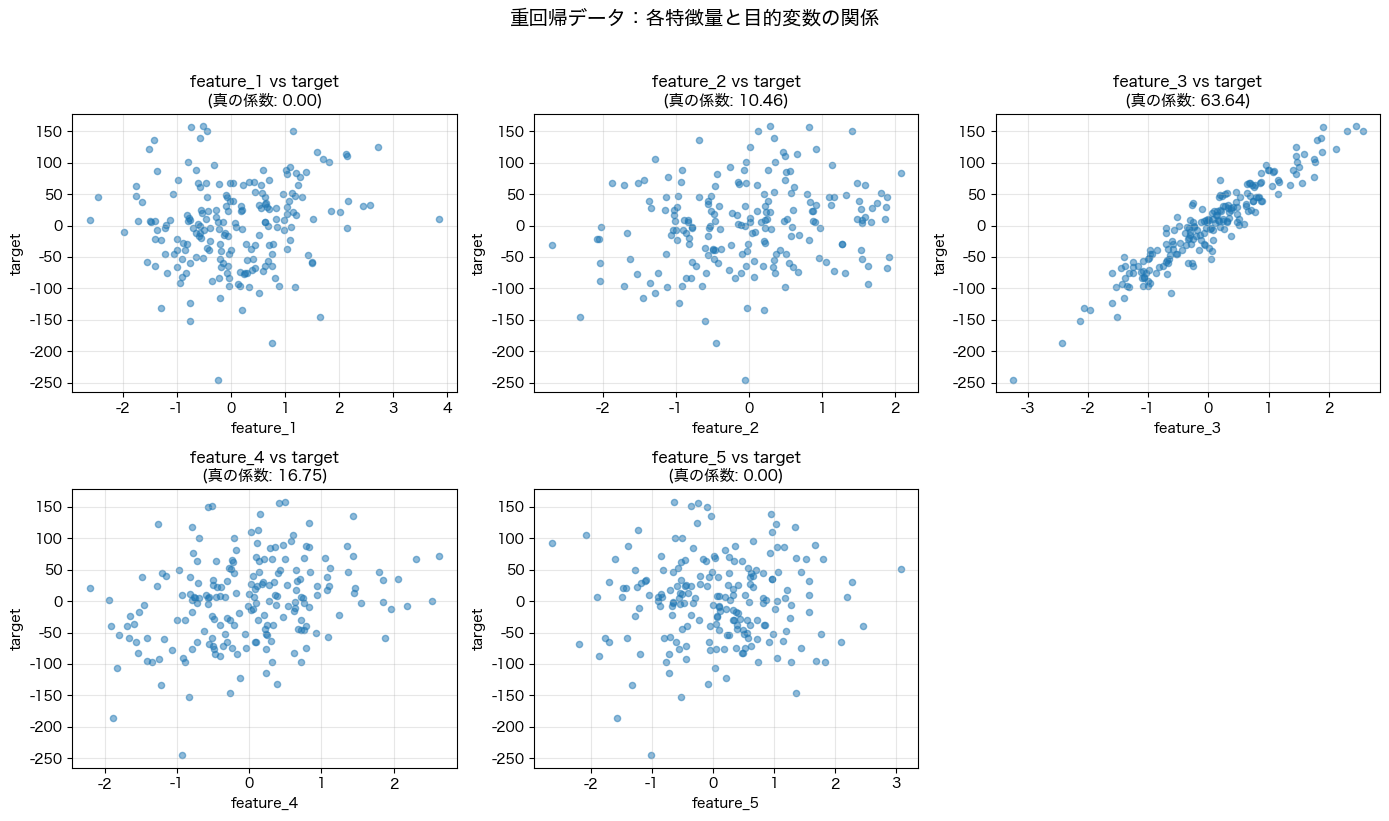

In [37]:
# 各特徴量と目的変数の関係を可視化
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].scatter(df_multi[col], df_multi['target'], alpha=0.5, s=20)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('target', fontsize=10)
    axes[i].set_title(f'{col} vs target\n(真の係数: {coef[i]:.2f})', fontsize=11)
    axes[i].grid(True, alpha=0.3)

# 最後のサブプロットを非表示
axes[-1].axis('off')

plt.suptitle('重回帰データ：各特徴量と目的変数の関係', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 3. データの保存

作成したデータセットをCSVファイルとして保存します。


In [38]:
# CSVファイルとして保存
df_simple.to_csv('../data/simple_linear_data.csv', index=False)
df_multi.to_csv('../data/multi_linear_data.csv', index=False)

print("データを保存しました:")
print("  - ../data/simple_linear_data.csv（単回帰用）")
print("  - ../data/multi_linear_data.csv（重回帰用）")


データを保存しました:
  - ../data/simple_linear_data.csv（単回帰用）
  - ../data/multi_linear_data.csv（重回帰用）


## 4. データセットのサマリー


In [39]:
print("=" * 50)
print("【単回帰データセット】")
print("=" * 50)
print(df_simple.describe())
print("\n")
print("=" * 50)
print("【重回帰データセット】")
print("=" * 50)
print(df_multi.describe())


【単回帰データセット】
                x           y
count  100.000000  100.000000
mean     4.701807   19.103262
std      2.974894    8.837473
min      0.055221    4.517970
25%      1.932008   11.572464
50%      4.641425   18.021013
75%      7.302031   27.029385
max      9.868869   36.170254


【重回帰データセット】
        feature_1   feature_2   feature_3   feature_4   feature_5      target
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000
mean     0.068897   -0.022597   -0.005246   -0.014466    0.070073   -0.232395
std      1.030185    0.999875    0.965776    0.934289    0.968691   66.891327
min     -2.619745   -2.696887   -3.241267   -2.211135   -2.650970 -244.775237
25%     -0.628305   -0.776155   -0.666198   -0.607065   -0.558032  -46.248849
50%     -0.027014   -0.029604    0.020669    0.035473    0.087022    4.495458
75%      0.713079    0.598342    0.634797    0.623554    0.671159   44.729313
max      3.852731    2.075401    2.560085    2.632382    3.078881  157.691479
